# Warehouse Route Optimization — Full Pipeline Plan

## Problem Statement
A warehouse has **5 levels**: Ground floor (floor 0) + Floors 1–4.
- **Floors 1–4**: Used for **pallet storage on the floor**. Storage cells are walkable if empty (remaining capacity > 0), blocked if full.
- **Ground floor (0)**: Contains **shelves** (not walkable — you pick from the aisle side), plus special zones: **VRAC**, **Zone d'Exhibition**, **Bureau**, aisles, elevators, chariot elevators, obstacles.

**Goal**: Given a **source** (a storage cell on floors 1–4) and a **target** (a shelf on the ground floor, or an exhibition zone), compute the **full minimized path** across floors, combining intra-floor BFS/A* pathfinding with inter-floor chariot elevator transit.

---

## Key Differences from Storage Optimization

| Aspect | Storage Opt (existing) | Route Opt (this notebook) |
|--------|----------------------|--------------------------|
| **Direction** | Chariot → storage cell (inbound) | Storage cell → shelf (outbound picking) |
| **Floors involved** | Single-floor BFS per floor | Cross-floor: source on floor 1–4, target on floor 0 |
| **Ground floor** | Not modeled | Fully modeled (shelves, VRAC, exhibition, bureau) |
| **Walkability** | Storage cell walkable if has capacity | Shelves are NEVER walkable (pick from adjacent aisle) |
| **Output** | Distance ranking + slot assignment | Full path (sequence of cells) + total cost |

---

## Pipeline Steps

### Step 0 — Setup & Constants
- Import libraries (numpy, pandas, collections.deque, heapq for A*)
- Define constants:
  - `CHARIOT_TRANSIT_COST_PER_FLOOR` — fixed time/cost to move between floors via chariot elevator (e.g., 10 units)
  - Movement costs: `STRAIGHT_COST = 1`, `DIAGONAL_COST` (if allowed, probably not in warehouse aisles)
- Load shared data: product features, emplacement metadata (reuse from storageOpt)

### Step 1 — Load & Build Raw Matrices (All 5 Levels)

#### Step 1a — Floors 1–4 (reuse existing)
- Load `Book1.csv` (floors 1 & 2 layout) and `Book2.csv` (floors 3 & 4 layout)
- Parse into `type_matrix` + `slot_matrix` per floor using existing `parse_floor_csv()`
- Encoding: `0`=aisle, `1`=storage cell, `2`=elevator, `3`=chariot elevator, `4`=obstacle

#### Step 1b — Ground Floor (NEW)
- **You need a CSV for the ground floor layout** (or build it manually)
- Extended encoding for ground floor:

| Value | Meaning |
|-------|---------|
| `0`   | Walkable aisle |
| `1`   | Shelf (NOT walkable — pick from adjacent aisle) |
| `2`   | Elevator |
| `3`   | Chariot elevator |
| `4`   | Obstacle (wall, pillar) |
| `5`   | VRAC zone (walkable — bulk storage area) |
| `6`   | Zone d'Exhibition (target zone — walkable) |
| `7`   | Bureau (office — obstacle, not walkable) |

- Parse into `type_matrix_ground` + `slot_matrix_ground`
- Slot matrix for ground floor: shelf IDs (e.g., `"S-A01"`, `"S-B03"`) instead of cell codes

**Adjustment**: Ground floor parser needs to handle the extended codes (5, 6, 7). Write a `parse_ground_floor_csv()` variant.

### Step 2 — Build Full Floor Dictionary

```python
floor_matrices = {
    0: {"type": type_matrix_ground, "slots": slot_matrix_ground},  # ground
    1: {"type": type_matrix_1,       "slots": slot_matrix_1},
    2: {"type": type_matrix_2,       "slots": slot_matrix_2},
    3: {"type": type_matrix_3,       "slots": slot_matrix_3},
    4: {"type": type_matrix_4,       "slots": slot_matrix_4},
}
```

Each entry holds:
- `type`: integer matrix (cell types)
- `slots`: string matrix (slot/shelf IDs or None)

### Step 3 — Build Metadata Lookup

A dictionary `metadata[floor][row][col]` → returns rich metadata:

```python
metadata[(floor, row, col)] = {
    "type": "storage" | "shelf" | "aisle" | "elevator" | "chariot" | "obstacle" | "vrac" | "exhibition" | "bureau",
    "slot_id": "C-12" or "S-A01" or None,
    "floor": 0–4,
    "walkable": True/False,        # pre-computed
    "emplacement_id": "EMP-xxx",   # if linked
    "capacity_remaining_m3": 5.2,  # if storage/shelf
}
```

**Why**: Single lookup point for any downstream algorithm — BFS checks `walkable`, assignment checks `capacity_remaining_m3`, reporting uses `slot_id`.

### Step 4 — Build Walkability Matrices

One binary matrix per floor: `walkability[floor]` where `1` = passable, `0` = blocked.

**Rules differ by floor**:

| Floor | Cell Type | Walkable? | Reason |
|-------|-----------|-----------|--------|
| 1–4 | Aisle (0) | ✅ Yes | Open path |
| 1–4 | Storage (1), has capacity | ✅ Yes | Pallet on floor, can walk through if not full |
| 1–4 | Storage (1), full | ❌ No | Blocked by product |
| 1–4 | Elevator (2) | ❌ No | Person-only, not used for routing |
| 1–4 | Chariot (3) | ✅ Yes | Entry/exit point |
| 1–4 | Obstacle (4) | ❌ No | Wall/pillar |
| 0 | Aisle (0) | ✅ Yes | Open path |
| 0 | Shelf (1) | ❌ No | Shelves block movement — pick from adjacent aisle |
| 0 | Elevator (2) | ❌ No | Not used |
| 0 | Chariot (3) | ✅ Yes | Entry/exit point |
| 0 | Obstacle (4) | ❌ No | Wall/pillar |
| 0 | VRAC (5) | ✅ Yes | Open bulk area |
| 0 | Exhibition (6) | ✅ Yes | Target zone, walkable |
| 0 | Bureau (7) | ❌ No | Office, blocked |

**Key difference**: On floors 1–4, storage cells CAN be walked through (they're pallets on the floor). On floor 0, shelves CANNOT be walked through (they're physical shelving units). You approach a shelf from an adjacent walkable aisle cell.

### Step 5 — Identify Sources & Targets

**Sources** (where product currently is):
- All storage cells on floors 1–4 where `type == 1` and a product is stored
- Represented as `(floor, row, col)`

**Targets** (where product needs to go):
- **Shelves** on ground floor: `type == 1` on floor 0 — but the actual reachable point is the **adjacent walkable aisle cell** (not the shelf itself)
- **Exhibition zones**: `type == 6` on floor 0

**Adjustment — Shelf adjacency**: Since shelves are not walkable, for each shelf target, pre-compute its **access points** = walkable neighbors (up/down/left/right). The path goes to the access point, not into the shelf.

```python
def get_access_points(floor_walkability, shelf_row, shelf_col):
    """Return list of (r, c) walkable cells adjacent to this shelf."""
    neighbors = [(shelf_row-1, shelf_col), (shelf_row+1, shelf_col),
                 (shelf_row, shelf_col-1), (shelf_row, shelf_col+1)]
    return [(r, c) for r, c in neighbors 
            if 0 <= r < H and 0 <= c < W and floor_walkability[r, c] == 1]
```

### Step 6 — Intra-Floor Distance Matrices (BFS from Chariot Elevators)

For **each floor** (0–4), run BFS from every chariot elevator position to compute shortest distances to all reachable cells.

```
dist_from_chariot[floor] = 2D matrix, dist_from_chariot[floor][r][c] = steps from chariot to (r,c)
```

**On floors 1–4**: BFS from chariot position, walking through aisles + non-full storage cells.
**On floor 0**: BFS from chariot position, walking through aisles + VRAC + exhibition zones (NOT through shelves).

This gives you the **intra-floor leg** of any path:
- Source → chariot on source floor
- Chariot on ground floor → target (shelf access point / exhibition zone)

### Step 7 — Inter-Floor Cost Model

Since chariot elevator transit between floors is a **fixed cost**, model it simply:

```
inter_floor_cost(src_floor, dst_floor) = |src_floor - dst_floor| × CHARIOT_TRANSIT_COST_PER_FLOOR
```

This assumes the chariot goes directly between floors (no stops). If it always goes to ground floor:
```
inter_floor_cost(src_floor) = src_floor × CHARIOT_TRANSIT_COST_PER_FLOOR
```

### Step 8 — Full Path Cost: Source → Target

The **total cost** from source `(floor_s, r_s, c_s)` to target `(0, r_t, c_t)` decomposes into 3 legs:

```
total_cost = leg_1 + leg_2 + leg_3
```

| Leg | Description | Computation |
|-----|-------------|-------------|
| **Leg 1** | Source cell → chariot elevator (on source floor) | `dist_from_chariot[floor_s][r_s][c_s]` (BFS distance, reversed) |
| **Leg 2** | Chariot ride: floor_s → floor 0 | `floor_s × CHARIOT_TRANSIT_COST_PER_FLOOR` |
| **Leg 3** | Chariot exit (floor 0) → target shelf access point | `dist_from_chariot[0][access_r][access_c]` (BFS distance on ground floor) |

If a shelf has multiple access points, take the **minimum** of leg 3 across all access points.

### Step 9 — Full Path Reconstruction (BFS or A*)

Once you know the optimal route cost-wise, reconstruct the **actual path** (sequence of cells) for visualization and execution.

**Option A — BFS (recommended for grid, unweighted)**:
- Simple, guarantees shortest path on unweighted grids
- Run BFS and store `parent[r][c]` to reconstruct path

**Option B — A\* (if you want weighted movement)**:
- Use Manhattan distance as heuristic
- Allows different movement costs (e.g., turning penalty, congestion zones)
- More complex but extensible

**Recommendation**: Start with **BFS** (simpler, sufficient for uniform-cost grid). Upgrade to A* later if you need weighted edges (e.g., "avoid congested aisles").

**Full path reconstruction**:
```
path = [
    (floor_s, r_s, c_s),          # start at source storage cell
    (floor_s, ..., ...),          # walk to chariot on source floor (BFS path)
    (floor_s, chariot_r, chariot_c),  # arrive at chariot
    --- chariot transit (floor_s → 0) ---
    (0, chariot_r_0, chariot_c_0),    # exit chariot on ground floor
    (0, ..., ...),                    # walk to shelf access point (BFS path)
    (0, access_r, access_c),          # arrive at shelf access point → pick
]
```

### Step 10 — Build Full Distance Matrix (All Sources × All Targets)

Compute a matrix `D[i][j]` where:
- `i` indexes all source cells (storage on floors 1–4)
- `j` indexes all target cells (shelves / exhibition on floor 0)
- `D[i][j]` = minimum total cost (leg 1 + leg 2 + leg 3)

This matrix is the input for:
- Finding the nearest shelf for a given product
- Optimizing picking routes (TSP-like if multiple picks)
- Heatmaps / analytics

### Step 11 — Visualization & Validation

1. **Per-floor heatmaps**: Color-code cells by distance from chariot
2. **Path overlay**: Draw the full multi-floor path on the floor layouts
3. **Ground floor map**: Show shelves, VRAC, exhibition, bureau with access points highlighted
4. **Sanity checks**:
   - Every shelf has at least one access point
   - Every storage cell is reachable from its floor's chariot
   - Total cost = leg 1 + leg 2 + leg 3 (verify decomposition)

---

## Summary of What I Adjusted / Added vs. Your Description

1. **Shelf access points**: You can't path INTO a shelf — I added the concept of computing adjacent walkable cells as the actual BFS target on the ground floor.

2. **3-leg cost decomposition**: Rather than one giant cross-floor BFS, I split the cost into 3 independent legs. This is much more efficient — you compute per-floor BFS once, then combine costs algebraically.

3. **Ground floor extended encoding**: Added codes 5 (VRAC), 6 (Exhibition), 7 (Bureau) with clear walkability rules.

4. **BFS over A\***: Recommended BFS first since your grid has uniform costs. A* adds complexity without benefit on unweighted grids. You can upgrade later.

5. **Metadata lookup**: Added a unified `(floor, row, col) → metadata` dictionary so all downstream steps (walkability, source/target identification, assignment) use one consistent data source.

6. **Distance matrix structure**: Instead of computing paths on-demand, pre-compute the full `sources × targets` distance matrix. This makes subsequent operations (nearest shelf lookup, picking optimization) O(1) lookups.

---

## Implementation Order (Recommended)

| Step | Depends On | Complexity |
|------|-----------|------------|
| 0. Setup | — | Low |
| 1a. Floors 1–4 matrices | Step 0 | Low (reuse existing) |
| 1b. Ground floor matrix | Step 0 | Medium (new CSV + parser) |
| 2. Full floor dict | Steps 1a, 1b | Low |
| 3. Metadata lookup | Step 2 | Medium |
| 4. Walkability matrices | Step 3 | Medium |
| 5. Sources & targets | Steps 3, 4 | Low |
| 6. Intra-floor BFS | Steps 4, 5 | Medium |
| 7. Inter-floor cost | — | Low |
| 8. Full path cost | Steps 6, 7 | Low |
| 9. Path reconstruction | Steps 6, 8 | Medium |
| 10. Distance matrix | Steps 8, 5 | Medium (computational) |
| 11. Visualization | Steps 6–10 | Medium |

---
## Step 0 — Setup & Constants

In [1]:
import numpy as np
import pandas as pd
import json
import re
from collections import deque
import heapq                       # for A* later if needed
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ══════════════════════════════════════════════════════════
# Constants  (mirrored from storageOpt where applicable)
# ══════════════════════════════════════════════════════════

# ── Capacity ──
MAX_CAPACITY_M3 = 10_000.0          # max capacity per emplacement (m³)

# ── Inter-floor transit ──
CHARIOT_TRANSIT_COST_PER_FLOOR = 10  # fixed cost (meter-equiv.) per floor via chariot elevator

# ── Movement costs (intra-floor grid) ──
STRAIGHT_COST = 1                    # cost to move 1 cell (up/down/left/right)

# ── Floor matrix cell-type codes ──
# Shared across floors 0-4
CODE_AISLE      = 0
CODE_STORAGE    = 1   # floors 1-4: pallet on floor  |  floor 0: shelf
CODE_ELEVATOR   = 2   # person elevator (not used for freight routing)
CODE_CHARIOT    = 3   # chariot elevator (freight — entry/exit point)
CODE_OBSTACLE   = 4   # wall / pillar

# Ground-floor only extensions
CODE_VRAC       = 5   # bulk storage area (walkable)
CODE_EXHIBITION = 6   # zone d'exhibition (walkable, target)
CODE_BUREAU     = 7   # office (not walkable)

# ── Human-readable labels ──
CODE_LABELS = {
    CODE_AISLE:      "Aisle",
    CODE_STORAGE:    "Storage/Shelf",
    CODE_ELEVATOR:   "Elevator",
    CODE_CHARIOT:    "Chariot Elevator",
    CODE_OBSTACLE:   "Obstacle",
    CODE_VRAC:       "VRAC",
    CODE_EXHIBITION: "Exhibition",
    CODE_BUREAU:     "Bureau",
}

# ── Data paths (relative to storageOpt — adjust if needed) ──
STORAGE_OPT_DIR = "../storageOpt"
CSV_FLOOR_12    = f"{STORAGE_OPT_DIR}/Book1.csv"     # layout for floors 1 & 2
CSV_FLOOR_34    = f"{STORAGE_OPT_DIR}/Book2.csv"     # layout for floors 3 & 4
CSV_EMPLACEMENTS = f"{STORAGE_OPT_DIR}/emplacements.csv"
CSV_PRODUITS     = f"{STORAGE_OPT_DIR}/produits.csv"
CSV_TRANSACTIONS = f"{STORAGE_OPT_DIR}/transactions.csv"
CSV_LIGNES       = f"{STORAGE_OPT_DIR}/lignes_transaction.csv"
JSON_AVAILABLE   = f"{STORAGE_OPT_DIR}/emplacement_available_slots.json"

# ── Print summary ──
print("✓ Step 0 — Imports & constants loaded")
print(f"  MAX_CAPACITY_M3            = {MAX_CAPACITY_M3} m³")
print(f"  CHARIOT_TRANSIT_COST_PER_FLOOR = {CHARIOT_TRANSIT_COST_PER_FLOOR}")
print(f"  STRAIGHT_COST              = {STRAIGHT_COST}")
print(f"  Cell-type codes: {CODE_LABELS}")
print(f"  Data dir: {STORAGE_OPT_DIR}")

✓ Step 0 — Imports & constants loaded
  MAX_CAPACITY_M3            = 10000.0 m³
  CHARIOT_TRANSIT_COST_PER_FLOOR = 10
  STRAIGHT_COST              = 1
  Cell-type codes: {0: 'Aisle', 1: 'Storage/Shelf', 2: 'Elevator', 3: 'Chariot Elevator', 4: 'Obstacle', 5: 'VRAC', 6: 'Exhibition', 7: 'Bureau'}
  Data dir: ../storageOpt


---
## Step 1 — Load & Build Floor Matrices (All 5 Levels)

### Floor CSV recap
| CSV | Floors | Format | Meaning of `(label)1` |
|-----|--------|--------|----------------------|
| `Book1.csv` (storageOpt) | 1 & 2 | `(A1)1`, `(B7)1` | Floor storage cells (pallets on floor) |
| `Book2.csv` (storageOpt) | 3 & 4 | Same | Floor storage cells |
| `Book3.csv` (routeOpt) | 0 (ground) | `(0W-01-01)1`, `(A)1` | Shelves (not walkable) |

### Ground floor shelf encoding — generalized from W
All shelf sections follow the same `{level}{section}-{shelf:02d}-{spot:02d}` format:
- **W section** (col 0): Already labeled explicitly in CSV → `0W-01-01` to `0W-05-03`
- **Single-letter sections** (A–V): CSV shows `(A)1`, `(V)1` etc. — shelf & spot numbers derived from row position using the same formula as W:
  ```
  shelf_zone_start = 7  (first row with shelf labels in Book3)
  shelf_num = (row - shelf_zone_start) // 3 + 1
  spot      = (row - shelf_zone_start) %  3 + 1
  slot_id   = f"0{letter}-{shelf_num:02d}-{spot:02d}"
  ```
- Each physical shelf position has **5 vertical levels** (0–4), but the CSV is the 2D plan view showing level 0 only.

In [6]:
# ══════════════════════════════════════════════════════════
# Step 1a — Parser functions
# ══════════════════════════════════════════════════════════

# ── Shared parser for upper floors (1–4) ──
# Reused from storageOpt — handles labels like (A1)1, (B7)1
def parse_upper_floor_csv(raw, rows, cols):
    """Parse a floor 1–4 CSV into type_matrix (int) and slot_matrix (str|None).
    
    Cell format examples:
        '0'         → aisle
        '(B7)1'     → storage cell, slot_id = 'B7'
        '3'         → chariot elevator
        '4'         → obstacle
    """
    type_mat = np.zeros((rows, cols), dtype=int)
    slot_mat = np.empty((rows, cols), dtype=object)

    for i in range(rows):
        for j in range(cols):
            cell = raw[i, j].strip()
            if not cell:
                type_mat[i, j] = CODE_AISLE
                slot_mat[i, j] = None
                continue
            if not cell[-1].isdigit():
                type_mat[i, j] = CODE_AISLE
                slot_mat[i, j] = None
                continue

            cell_type = int(cell[-1])
            type_mat[i, j] = cell_type

            if cell_type == CODE_STORAGE:
                match = re.search(r"\((.*?)\)", cell)
                slot_mat[i, j] = match.group(1) if match else None
            else:
                slot_mat[i, j] = None

    return type_mat, slot_mat


# ── Ground floor parser ──
# Handles extended codes 0–7 and generalizes shelf slot IDs

SHELF_ZONE_START_ROW = 7       # first row in Book3.csv that contains shelf labels
SHELF_SPOTS_PER_SHELF = 3      # 3 rows per shelf for every section
SHELF_LEVELS = 5               # vertical levels 0–4 per physical shelf position

# Regex patterns
RE_FULL_SHELF  = re.compile(r"\((\d[A-Z]-\d{2}-\d{2})\)")   # e.g. (0W-01-01)
RE_SINGLE_LETTER = re.compile(r"\(([A-Z])\)")                 # e.g. (A)

def parse_ground_floor_csv(raw, rows, cols):
    """Parse ground floor (Book3) CSV into type_matrix and slot_matrix.
    
    Cell types 0–7 are supported.
    Shelf slot IDs are generalized: single-letter shelves like (A)1 get
    a full ID  '{level}{section}-{shelf:02d}-{spot:02d}'  computed from
    their row position relative to that section's first appearance row,
    so every section starts numbering from 01-01.
    """
    # ── Pass 1: find the first row each single-letter section appears ──
    section_first_row = {}   # e.g. {'A': 7, 'B': 15, ...}
    for i in range(rows):
        for j in range(cols):
            cell = raw[i, j].strip()
            if not cell or not cell[-1].isdigit():
                continue
            if int(cell[-1]) != CODE_STORAGE:
                continue
            m = RE_SINGLE_LETTER.search(cell)
            if m:
                sec = m.group(1)
                if sec not in section_first_row:
                    section_first_row[sec] = i

    # ── Pass 2: build type_matrix + slot_matrix ──
    type_mat = np.zeros((rows, cols), dtype=int)
    slot_mat = np.empty((rows, cols), dtype=object)

    for i in range(rows):
        for j in range(cols):
            cell = raw[i, j].strip()

            # ── empty / non-digit ending → aisle ──
            if not cell:
                type_mat[i, j] = CODE_AISLE
                slot_mat[i, j] = None
                continue
            if not cell[-1].isdigit():
                type_mat[i, j] = CODE_AISLE
                slot_mat[i, j] = None
                continue

            cell_type = int(cell[-1])
            type_mat[i, j] = cell_type

            if cell_type != CODE_STORAGE:
                slot_mat[i, j] = None
                continue

            # ── It's a shelf (type 1). Figure out the slot ID. ──

            # Case 1: already fully labeled  (0W-01-01)
            m_full = RE_FULL_SHELF.search(cell)
            if m_full:
                slot_mat[i, j] = m_full.group(1)
                continue

            # Case 2: single-letter label  (A)
            m_letter = RE_SINGLE_LETTER.search(cell)
            if m_letter:
                section = m_letter.group(1)
                start = section_first_row[section]
                shelf_num = (i - start) // SHELF_SPOTS_PER_SHELF + 1
                spot      = (i - start) %  SHELF_SPOTS_PER_SHELF + 1
                slot_mat[i, j] = f"0{section}-{shelf_num:02d}-{spot:02d}"
                continue

            # Case 3: type 1 but no label at all (shouldn't happen, but safe)
            slot_mat[i, j] = None

    return type_mat, slot_mat


print("✓ Step 1a — Parser functions defined")
print(f"  SHELF_ZONE_START_ROW  = {SHELF_ZONE_START_ROW}")
print(f"  SHELF_SPOTS_PER_SHELF = {SHELF_SPOTS_PER_SHELF}")
print(f"  SHELF_LEVELS          = {SHELF_LEVELS} (vertical levels 0–4)")

✓ Step 1a — Parser functions defined
  SHELF_ZONE_START_ROW  = 7
  SHELF_SPOTS_PER_SHELF = 3
  SHELF_LEVELS          = 5 (vertical levels 0–4)


In [7]:
# ══════════════════════════════════════════════════════════
# Step 1b — Load all CSVs & build floor_matrices
# ══════════════════════════════════════════════════════════

# ── Upper floors (1–4) from storageOpt ──
raw_12 = np.genfromtxt(CSV_FLOOR_12, delimiter=",", dtype=str)
raw_34 = np.genfromtxt(CSV_FLOOR_34, delimiter=",", dtype=str)

type_mat_12, slot_mat_12 = parse_upper_floor_csv(raw_12, *raw_12.shape)
type_mat_34, slot_mat_34 = parse_upper_floor_csv(raw_34, *raw_34.shape)

# ── Ground floor (0) from routeOpt ──
CSV_GROUND = "Book3.csv"
raw_ground = np.genfromtxt(CSV_GROUND, delimiter=",", dtype=str)
type_mat_ground, slot_mat_ground = parse_ground_floor_csv(raw_ground, *raw_ground.shape)

# ── Assemble floor_matrices dict ──
# Floors 1&2 share Book1 layout, floors 3&4 share Book2 layout
floor_matrices = {
    0: {"type": type_mat_ground,       "slots": slot_mat_ground},
    1: {"type": type_mat_12.copy(),    "slots": slot_mat_12.copy()},
    2: {"type": type_mat_12.copy(),    "slots": slot_mat_12.copy()},
    3: {"type": type_mat_34.copy(),    "slots": slot_mat_34.copy()},
    4: {"type": type_mat_34.copy(),    "slots": slot_mat_34.copy()},
}

# ── Summary ──
print("✓ Step 1b — floor_matrices built for 5 floors\n")
for fl in range(5):
    t = floor_matrices[fl]["type"]
    s = floor_matrices[fl]["slots"]
    shape = f"{t.shape[0]}×{t.shape[1]}"

    # Count cell types
    type_counts = {CODE_LABELS.get(v, f"?{v}"): int(np.sum(t == v))
                   for v in sorted(np.unique(t))}
    
    # Count slots with IDs
    slot_ids = [s[i, j] for i in range(t.shape[0]) for j in range(t.shape[1])
                if s[i, j] is not None]
    n_slots = len(slot_ids)
    unique_slots = len(set(slot_ids))

    floor_label = "Ground" if fl == 0 else f"Floor {fl}"
    print(f"  {floor_label} ({shape}):  {type_counts}")
    print(f"    → {n_slots} slot cells ({unique_slots} unique IDs)")

✓ Step 1b — floor_matrices built for 5 floors

  Ground (25×43):  {'Aisle': 627, 'Storage/Shelf': 144, 'Elevator': 10, 'Chariot Elevator': 24, 'Obstacle': 43, 'VRAC': 71, 'Exhibition': 72, 'Bureau': 84}
    → 144 slot cells (144 unique IDs)
  Floor 1 (30×45):  {'Aisle': 659, 'Storage/Shelf': 617, 'Elevator': 15, 'Chariot Elevator': 30, 'Obstacle': 29}
    → 617 slot cells (50 unique IDs)
  Floor 2 (30×45):  {'Aisle': 659, 'Storage/Shelf': 617, 'Elevator': 15, 'Chariot Elevator': 30, 'Obstacle': 29}
    → 617 slot cells (50 unique IDs)
  Floor 3 (30×44):  {'Aisle': 715, 'Storage/Shelf': 518, 'Elevator': 20, 'Chariot Elevator': 30, 'Obstacle': 37}
    → 518 slot cells (55 unique IDs)
  Floor 4 (30×44):  {'Aisle': 715, 'Storage/Shelf': 518, 'Elevator': 20, 'Chariot Elevator': 30, 'Obstacle': 37}
    → 518 slot cells (55 unique IDs)


In [8]:
# ══════════════════════════════════════════════════════════
# Step 1c — Inspect ground floor shelf slots (sanity check)
# ══════════════════════════════════════════════════════════

t0 = floor_matrices[0]["type"]
s0 = floor_matrices[0]["slots"]
rows_0, cols_0 = t0.shape

# ── Collect all shelf sections and their slot IDs + positions ──
shelf_sections = {}   # section_letter → list of (row, col, slot_id)

for i in range(rows_0):
    for j in range(cols_0):
        if t0[i, j] == CODE_STORAGE and s0[i, j] is not None:
            sid = s0[i, j]
            # Extract the section letter (2nd char: "0W-..." → W, "0A-..." → A)
            section = sid[1]
            shelf_sections.setdefault(section, []).append((i, j, sid))

# ── Pretty-print by section ──
print("✓ Ground floor shelf sections\n")
print(f"{'Section':<10} {'Column':<8} {'Shelves':<8} {'Slots':<8} {'Slot ID range'}")
print("─" * 65)

for sec in sorted(shelf_sections.keys()):
    entries = shelf_sections[sec]
    cols_used = sorted(set(e[1] for e in entries))
    slot_ids = sorted(set(e[2] for e in entries))
    n_shelves = len(set(sid.split("-")[1] for sid in slot_ids))
    print(f"  {sec:<8} col {','.join(map(str,cols_used)):<5} {n_shelves:<8} {len(slot_ids):<8} {slot_ids[0]} → {slot_ids[-1]}")

print(f"\n  Total sections: {len(shelf_sections)}")
print(f"  Total shelf slots: {sum(len(v) for v in shelf_sections.values())}")

# ── Also show a visual snippet: slot_matrix for the shelf zone ──
print(f"\n── Slot matrix (rows {SHELF_ZONE_START_ROW}–{min(SHELF_ZONE_START_ROW+8, rows_0-1)}, cols 0–27) ──")
for i in range(SHELF_ZONE_START_ROW, min(SHELF_ZONE_START_ROW + 9, rows_0)):
    row_str = []
    for j in range(min(28, cols_0)):
        sid = s0[i, j]
        if sid is not None:
            row_str.append(f"{sid:>12s}")
        else:
            code = t0[i, j]
            label = {0: ".", 2: "ELV", 3: "CHR", 4: "███", 5: "VRC", 6: "EXH", 7: "BUR"}.get(code, "?")
            row_str.append(f"{label:>12s}")
    print(f"  Row {i:2d}: {''.join(row_str)}")

✓ Ground floor shelf sections

Section    Column   Shelves  Slots    Slot ID range
─────────────────────────────────────────────────────────────────
  A        col 25    2        5        0A-01-01 → 0A-02-02
  B        col 25    3        9        0B-01-01 → 0B-03-03
  C        col 24    2        6        0C-01-01 → 0C-02-03
  D        col 21    3        9        0D-01-01 → 0D-03-03
  E        col 20    2        6        0E-01-01 → 0E-02-03
  F        col 20    3        8        0F-01-01 → 0F-03-03
  G        col 16    2        6        0G-01-01 → 0G-02-03
  H        col 16    3        9        0H-01-01 → 0H-03-03
  I        col 15    2        6        0I-01-01 → 0I-02-03
  K        col 15    3        9        0K-01-01 → 0K-03-03
  M        col 11    2        5        0M-01-01 → 0M-02-02
  N        col 11    3        8        0N-01-01 → 0N-03-03
  P        col 10    2        6        0P-01-01 → 0P-02-03
  Q        col 10    3        9        0Q-01-01 → 0Q-03-03
  R        col 5     2   

---
## Step 2 — Build Metadata Lookup

A unified dictionary keyed by `(floor, row, col)` that gives rich metadata for any cell.  
This is the **single source of truth** for all downstream steps (walkability, BFS, assignment…).

For **floors 1–4** (storage cells), we also look up emplacement capacity from storageOpt data.  
For **floor 0** (shelves), each shelf position has 5 vertical levels (0–4) with capacity info.

In [45]:
# ══════════════════════════════════════════════════════════
# Step 2a — Load emplacement data & slot-capacity placeholder
# ══════════════════════════════════════════════════════════

# ── Emplacement master data (used for reference only) ──
emplacements_df = pd.read_csv(CSV_EMPLACEMENTS)
print(f"✓ Loaded emplacements: {len(emplacements_df)} total")

# ── Slot capacity: empty dict → no capacity-based walkability ──
# Upper-floor storage cells will be treated as BLOCKED for pathfinding
# (forklifts drive through aisles, not through racked pallets).
slot_capacity = {}

print(f"✓ slot_capacity = {{}}  (empty — storage cells blocked on upper floors)")
print(f"✓ Step 2a complete")

✓ Loaded emplacements: 840 total
✓ slot_capacity = {}  (empty — storage cells blocked on upper floors)
✓ Step 2a complete


In [46]:
# ══════════════════════════════════════════════════════════
# Step 2b — Build metadata lookup: (floor, row, col) → info
# ══════════════════════════════════════════════════════════

# Type code → human-readable type name (differs ground vs upper)
TYPE_NAME_UPPER = {
    CODE_AISLE:    "aisle",
    CODE_STORAGE:  "storage",     # pallet on floor
    CODE_ELEVATOR: "elevator",
    CODE_CHARIOT:  "chariot",
    CODE_OBSTACLE: "obstacle",
}
TYPE_NAME_GROUND = {
    CODE_AISLE:      "aisle",
    CODE_STORAGE:    "shelf",      # physical shelving unit
    CODE_ELEVATOR:   "elevator",
    CODE_CHARIOT:    "chariot",
    CODE_OBSTACLE:   "obstacle",
    CODE_VRAC:       "vrac",
    CODE_EXHIBITION: "exhibition",
    CODE_BUREAU:     "bureau",
}

metadata = {}  # (floor, row, col) → dict

for fl in range(5):
    t = floor_matrices[fl]["type"]
    s = floor_matrices[fl]["slots"]
    rows_f, cols_f = t.shape
    is_ground = (fl == 0)
    type_names = TYPE_NAME_GROUND if is_ground else TYPE_NAME_UPPER

    for i in range(rows_f):
        for j in range(cols_f):
            code = int(t[i, j])
            slot_id = s[i, j]  # str or None
            type_name = type_names.get(code, f"unknown_{code}")

            entry = {
                "type":      type_name,
                "type_code": code,
                "floor":     fl,
                "row":       i,
                "col":       j,
                "slot_id":   slot_id,
            }
            metadata[(fl, i, j)] = entry

# ── Summary stats ──
print(f"✓ Step 2b — metadata lookup built: {len(metadata):,} entries\n")

for fl in range(5):
    fl_entries = {k: v for k, v in metadata.items() if k[0] == fl}
    types = {}
    with_slot = 0
    for e in fl_entries.values():
        types[e["type"]] = types.get(e["type"], 0) + 1
        if e["slot_id"]:
            with_slot += 1

    floor_label = "Ground" if fl == 0 else f"Floor {fl}"
    print(f"  {floor_label}: {len(fl_entries)} cells — {types}")
    print(f"    slots with IDs: {with_slot}")

✓ Step 2b — metadata lookup built: 6,415 entries

  Ground: 1075 cells — {'aisle': 627, 'obstacle': 43, 'vrac': 71, 'chariot': 24, 'elevator': 10, 'shelf': 144, 'exhibition': 72, 'bureau': 84}
    slots with IDs: 144
  Floor 1: 1350 cells — {'aisle': 659, 'storage': 617, 'obstacle': 29, 'chariot': 30, 'elevator': 15}
    slots with IDs: 617
  Floor 2: 1350 cells — {'aisle': 659, 'storage': 617, 'obstacle': 29, 'chariot': 30, 'elevator': 15}
    slots with IDs: 617
  Floor 3: 1320 cells — {'storage': 518, 'aisle': 715, 'obstacle': 37, 'chariot': 30, 'elevator': 20}
    slots with IDs: 518
  Floor 4: 1320 cells — {'storage': 518, 'aisle': 715, 'obstacle': 37, 'chariot': 30, 'elevator': 20}
    slots with IDs: 518


In [47]:
# ══════════════════════════════════════════════════════════
# Step 2c — Metadata lookup demo / sanity check
# ══════════════════════════════════════════════════════════

demo_keys = [
    (0, 7, 0),    # ground floor, first W shelf
    (0, 7, 25),   # ground floor, first A shelf
    (0, 3, 28),   # ground floor, chariot area
    (0, 0, 28),   # ground floor, VRAC area
    (0, 7, 34),   # ground floor, exhibition area
    (0, 18, 29),  # ground floor, bureau area
    (1, 0, 1),    # floor 1, storage cell
    (1, 4, 29),   # floor 1, chariot
]

print("✓ Step 2c — Sample metadata lookups\n")
for key in demo_keys:
    m = metadata.get(key)
    if m:
        print(f"  {key} → type={m['type']:<12s} slot={str(m['slot_id']):<14s}")
    else:
        print(f"  {key} → NOT FOUND")

# ── Quick count ──
storage_total = sum(1 for v in metadata.values()
                    if v["type"] in ("storage", "shelf"))
print(f"\n  Total storage/shelf cells: {storage_total}")

✓ Step 2c — Sample metadata lookups

  (0, 7, 0) → type=shelf        slot=0W-01-01      
  (0, 7, 25) → type=shelf        slot=0A-01-01      
  (0, 3, 28) → type=chariot      slot=None          
  (0, 0, 28) → type=vrac         slot=None          
  (0, 7, 34) → type=exhibition   slot=None          
  (0, 18, 29) → type=bureau       slot=None          
  (1, 0, 1) → type=storage      slot=B7            
  (1, 4, 29) → type=chariot      slot=None          

  Total storage/shelf cells: 2414


---
## Step 3 — Build Walkability Matrices

One binary matrix per floor: `walkability[floor]` where `1` = passable, `0` = blocked.

**Rules differ by floor**:

| Floor | Cell Type | Walkable? |
|-------|-----------|-----------|
| 1–4 | Aisle (0) | ✅ |
| 1–4 | Storage (1), has capacity | ✅ |
| 1–4 | Storage (1), full | ❌ |
| 1–4 | Chariot (3) | ✅ |
| 1–4 | Elevator (2), Obstacle (4) | ❌ |
| 0 | Aisle (0), VRAC (5), Exhibition (6) | ✅ |
| 0 | Chariot (3) | ✅ |
| 0 | Shelf (1), Elevator (2), Obstacle (4), Bureau (7) | ❌ |

> Since `slot_capacity` is empty, **all storage cells on floors 1–4 default to walkable** (assumed not full).

In [54]:
# ══════════════════════════════════════════════════════════
# Step 3a — Build walkability matrices (one per floor)
# ══════════════════════════════════════════════════════════
#
# Values:
#   0 = blocked      (obstacles, ground-floor shelves, elevators, bureau)
#   1 = walkable     (aisles, chariots — full transit)
#   2 = dead-end     (upper-floor storage — reachable but BFS won't expand through)

WALKABLE_GROUND = {CODE_AISLE, CODE_CHARIOT, CODE_VRAC, CODE_EXHIBITION}
WALKABLE_UPPER  = {CODE_AISLE, CODE_CHARIOT}   # full transit
DEADEND_UPPER   = {CODE_STORAGE}               # reachable, not transit

walkability = {}  # floor → 2D np.ndarray (0/1/2)

for fl in range(5):
    t = floor_matrices[fl]["type"]
    rows_f, cols_f = t.shape
    w = np.zeros((rows_f, cols_f), dtype=int)

    if fl == 0:
        # Ground floor: shelves are NEVER walkable
        for i in range(rows_f):
            for j in range(cols_f):
                if int(t[i, j]) in WALKABLE_GROUND:
                    w[i, j] = 1
    else:
        # Upper floors: aisles/chariots = 1, storage = 2 (dead-end)
        for i in range(rows_f):
            for j in range(cols_f):
                code = int(t[i, j])
                if code in WALKABLE_UPPER:
                    w[i, j] = 1
                elif code in DEADEND_UPPER:
                    w[i, j] = 2

    walkability[fl] = w

# ── Summary ──
print("✓ Step 3a — Walkability matrices built\n")
print("  Legend: 1=walkable (transit), 2=dead-end (reachable, no transit), 0=blocked\n")
for fl in range(5):
    w = walkability[fl]
    total = w.size
    transit  = int(np.sum(w == 1))
    deadend  = int(np.sum(w == 2))
    blocked  = total - transit - deadend
    floor_label = "Ground" if fl == 0 else f"Floor {fl}"
    print(f"  {floor_label} ({w.shape[0]}×{w.shape[1]}): "
          f"{transit} transit, {deadend} dead-end, {blocked} blocked")

✓ Step 3a — Walkability matrices built

  Legend: 1=walkable (transit), 2=dead-end (reachable, no transit), 0=blocked

  Ground (25×43): 794 transit, 0 dead-end, 281 blocked
  Floor 1 (30×45): 689 transit, 617 dead-end, 44 blocked
  Floor 2 (30×45): 689 transit, 617 dead-end, 44 blocked
  Floor 3 (30×44): 745 transit, 518 dead-end, 57 blocked
  Floor 4 (30×44): 745 transit, 518 dead-end, 57 blocked


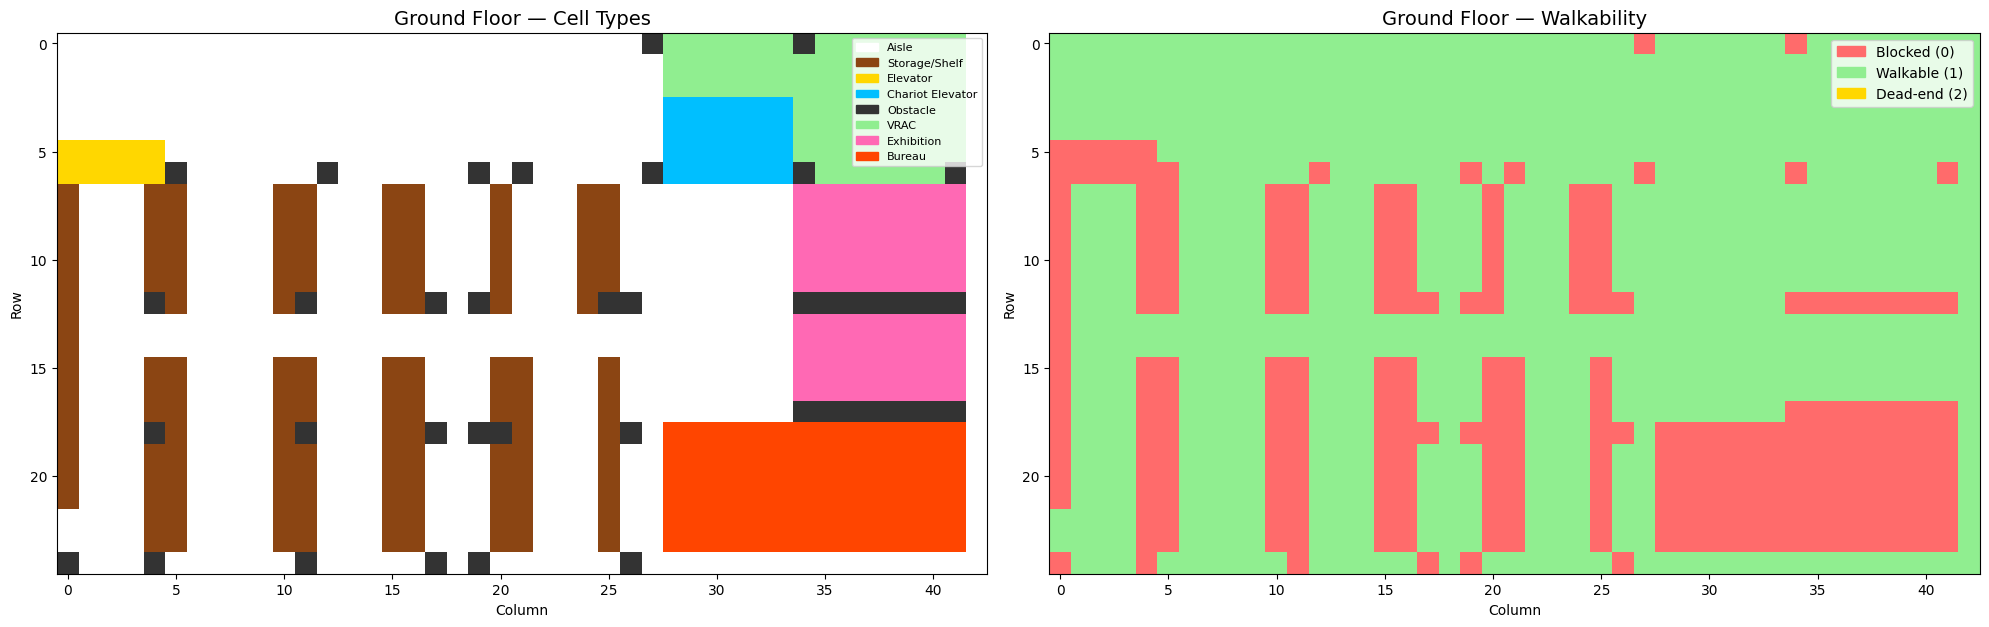


Chariot positions on ground floor: [(3, 28), (3, 29), (3, 30), (3, 31), (3, 32), (3, 33), (4, 28), (4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (5, 28), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (6, 28), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33)]
  (3,28) walkable=1
  (3,29) walkable=1
  (3,30) walkable=1
  (3,31) walkable=1
  (3,32) walkable=1
  (3,33) walkable=1
  (4,28) walkable=1
  (4,29) walkable=1
  (4,30) walkable=1
  (4,31) walkable=1
  (4,32) walkable=1
  (4,33) walkable=1
  (5,28) walkable=1
  (5,29) walkable=1
  (5,30) walkable=1
  (5,31) walkable=1
  (5,32) walkable=1
  (5,33) walkable=1
  (6,28) walkable=1
  (6,29) walkable=1
  (6,30) walkable=1
  (6,31) walkable=1
  (6,32) walkable=1
  (6,33) walkable=1


In [55]:
# ══════════════════════════════════════════════════════════
# Step 3b — Walkability visualization (ground floor)
# ══════════════════════════════════════════════════════════

t0 = floor_matrices[0]["type"]
w0 = walkability[0]

cmap_colors = [
    "#FFFFFF",  # 0 aisle       — white
    "#8B4513",  # 1 shelf       — brown
    "#FFD700",  # 2 elevator    — gold
    "#00BFFF",  # 3 chariot     — blue
    "#333333",  # 4 obstacle    — dark gray
    "#90EE90",  # 5 VRAC        — light green
    "#FF69B4",  # 6 exhibition  — pink
    "#FF4500",  # 7 bureau      — red-orange
]
cmap = ListedColormap(cmap_colors)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Left: cell types ──
ax1 = axes[0]
im1 = ax1.imshow(t0.astype(int), cmap=cmap, vmin=0, vmax=7, aspect='equal')
ax1.set_title("Ground Floor — Cell Types", fontsize=14)
ax1.set_xlabel("Column")
ax1.set_ylabel("Row")
patches = [mpatches.Patch(color=cmap_colors[i], label=CODE_LABELS.get(i, f"?{i}"))
           for i in range(8)]
ax1.legend(handles=patches, loc='upper right', fontsize=8)

# ── Right: walkability (3-value: 0=blocked, 1=transit, 2=dead-end) ──
ax2 = axes[1]
walk_cmap = ListedColormap(["#FF6B6B", "#90EE90", "#FFD700"])  # red, green, gold
im2 = ax2.imshow(w0, cmap=walk_cmap, vmin=0, vmax=2, aspect='equal')
ax2.set_title("Ground Floor — Walkability", fontsize=14)
ax2.set_xlabel("Column")
ax2.set_ylabel("Row")
walk_patches = [
    mpatches.Patch(color="#FF6B6B", label="Blocked (0)"),
    mpatches.Patch(color="#90EE90", label="Walkable (1)"),
    mpatches.Patch(color="#FFD700", label="Dead-end (2)"),
]
ax2.legend(handles=walk_patches, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ── Quick sanity: chariot positions should be walkable ──
chariot_positions = list(zip(*np.where(t0 == CODE_CHARIOT)))
print(f"\nChariot positions on ground floor: {chariot_positions}")
for r, c in chariot_positions:
    print(f"  ({r},{c}) walkable={w0[r,c]}")  # should all be 1

---
## Step 4 — Identify Sources & Targets

**Sources**: All storage cells on floors 1–4 (type=1) — where product is stored.  
**Targets**: Shelf cells on ground floor (type=1) + Exhibition zones (type=6).

Since shelves are **not walkable**, we pre-compute **access points** for each shelf = adjacent walkable aisle cells.  
The BFS path goes to the access point, not into the shelf itself.

In [56]:
# ══════════════════════════════════════════════════════════
# Step 4a — Identify sources (storage cells on floors 1–4)
# ══════════════════════════════════════════════════════════

sources = []  # list of (floor, row, col)

for fl in range(1, 5):
    t = floor_matrices[fl]["type"]
    s = floor_matrices[fl]["slots"]
    rows_f, cols_f = t.shape
    for i in range(rows_f):
        for j in range(cols_f):
            if int(t[i, j]) == CODE_STORAGE and s[i, j] is not None:
                sources.append((fl, i, j))

print(f"✓ Step 4a — Sources identified: {len(sources)} storage cells on floors 1–4\n")

# Breakdown per floor
for fl in range(1, 5):
    count = sum(1 for s in sources if s[0] == fl)
    print(f"  Floor {fl}: {count} storage cells")

✓ Step 4a — Sources identified: 2270 storage cells on floors 1–4

  Floor 1: 617 storage cells
  Floor 2: 617 storage cells
  Floor 3: 518 storage cells
  Floor 4: 518 storage cells


In [57]:
# ══════════════════════════════════════════════════════════
# Step 4b — Identify targets + compute shelf access points
# ══════════════════════════════════════════════════════════

def get_access_points(walk_mat, row, col):
    """Return list of (r, c) walkable cells adjacent to (row, col)."""
    H, W = walk_mat.shape
    neighbors = [(row-1, col), (row+1, col), (row, col-1), (row, col+1)]
    return [(r, c) for r, c in neighbors
            if 0 <= r < H and 0 <= c < W and walk_mat[r, c] == 1]


t0 = floor_matrices[0]["type"]
s0 = floor_matrices[0]["slots"]
w0 = walkability[0]
rows_0, cols_0 = t0.shape

# ── Shelf targets ──
# Each shelf cell → its access points (walkable neighbors)
shelf_targets = {}  # slot_id → {"cells": [(row, col), ...], "access_points": [(row, col), ...]}

for i in range(rows_0):
    for j in range(cols_0):
        if int(t0[i, j]) == CODE_STORAGE and s0[i, j] is not None:
            sid = s0[i, j]
            if sid not in shelf_targets:
                shelf_targets[sid] = {"cells": [], "access_points": set()}
            shelf_targets[sid]["cells"].append((i, j))
            # Find walkable neighbors for this shelf cell
            aps = get_access_points(w0, i, j)
            shelf_targets[sid]["access_points"].update(aps)

# Convert sets to sorted lists
for sid in shelf_targets:
    shelf_targets[sid]["access_points"] = sorted(shelf_targets[sid]["access_points"])

# ── Exhibition targets ──
# Exhibition zones are walkable — the target IS the cell itself
exhibition_targets = []  # list of (row, col)

for i in range(rows_0):
    for j in range(cols_0):
        if int(t0[i, j]) == CODE_EXHIBITION:
            exhibition_targets.append((i, j))

# ── Summary ──
print(f"✓ Step 4b — Targets identified on ground floor\n")
print(f"  Shelf targets:      {len(shelf_targets)} unique shelf IDs")
print(f"  Exhibition targets:  {len(exhibition_targets)} cells")

# Sanity: check shelves without access points (would be unreachable!)
no_access = [sid for sid, info in shelf_targets.items() if len(info["access_points"]) == 0]
if no_access:
    print(f"\n  ⚠ WARNING: {len(no_access)} shelves have NO access points (unreachable):")
    for sid in no_access[:10]:
        print(f"    {sid} at cells {shelf_targets[sid]['cells']}")
else:
    print(f"  ✓ All shelves have at least one access point")

# Show a few examples
print(f"\n── Sample shelf targets ──")
for sid in sorted(shelf_targets.keys())[:5]:
    info = shelf_targets[sid]
    print(f"  {sid}: cells={info['cells']}, access_points={info['access_points']}")

✓ Step 4b — Targets identified on ground floor

  Shelf targets:      144 unique shelf IDs
  Exhibition targets:  72 cells

  ⚠ WARNING: 1 shelves have NO access points (unreachable):
    0H-02-01 at cells [(18, 16)]

── Sample shelf targets ──
  0A-01-01: cells=[(7, 25)], access_points=[(6, 25), (7, 26)]
  0A-01-02: cells=[(8, 25)], access_points=[(8, 26)]
  0A-01-03: cells=[(9, 25)], access_points=[(9, 26)]
  0A-02-01: cells=[(10, 25)], access_points=[(10, 26)]
  0A-02-02: cells=[(11, 25)], access_points=[(11, 26)]


---
## Step 5 — Intra-Floor BFS + Inter-Floor Cost

**BFS from each chariot elevator** on every floor → gives shortest distance from chariot to all reachable cells.

This produces the two intra-floor legs of any cross-floor path:
- **Leg 1**: source storage cell → chariot (on source floor)
- **Leg 3**: chariot exit (ground floor) → target shelf access point

**Inter-floor cost** (Leg 2) is simply: `source_floor × CHARIOT_TRANSIT_COST_PER_FLOOR`

In [58]:
# ══════════════════════════════════════════════════════════
# Step 5a — BFS function + compute distance from chariot on each floor
# ══════════════════════════════════════════════════════════

def bfs_from(walk_mat, start_r, start_c):
    """BFS from (start_r, start_c) using a walkability matrix.
    
    walk_mat values:
        0 = blocked       → never visited
        1 = walkable      → visited AND expanded (transit cells)
        2 = dead-end      → visited but NOT expanded (storage cells)
    
    Dead-end (2) cells can be reached from adjacent walkable cells
    but the BFS does not expand from them, so paths cannot cut
    through storage racks.
    
    Returns 2D distance matrix (int): dist[r][c] = shortest steps, or -1.
    """
    H, W = walk_mat.shape
    dist = np.full((H, W), -1, dtype=int)
    dist[start_r, start_c] = 0
    queue = deque([(start_r, start_c)])

    while queue:
        r, c = queue.popleft()
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and walk_mat[nr, nc] >= 1 and dist[nr, nc] == -1:
                dist[nr, nc] = dist[r, c] + STRAIGHT_COST
                # Only expand from transit cells (1), not dead-ends (2)
                if walk_mat[nr, nc] == 1:
                    queue.append((nr, nc))

    return dist


# ── Find chariot positions on each floor ──
chariot_positions_per_floor = {}  # floor → list of (row, col)
for fl in range(5):
    t = floor_matrices[fl]["type"]
    positions = list(zip(*np.where(t == CODE_CHARIOT)))
    chariot_positions_per_floor[fl] = positions

print("✓ Chariot elevator positions per floor:")
for fl in range(5):
    label = "Ground" if fl == 0 else f"Floor {fl}"
    print(f"  {label}: {chariot_positions_per_floor[fl]}")

# ── Run BFS from each chariot on each floor ──
dist_from_chariot = {}  # floor → [(chariot_r, chariot_c, dist_2d), ...]

for fl in range(5):
    w = walkability[fl]
    chariots = chariot_positions_per_floor[fl]
    floor_dists = []

    for cr, cc in chariots:
        d = bfs_from(w, cr, cc)
        floor_dists.append((cr, cc, d))

    dist_from_chariot[fl] = floor_dists

# ── Summary ──
print(f"\n✓ Step 5a — BFS distance matrices computed\n")
for fl in range(5):
    label = "Ground" if fl == 0 else f"Floor {fl}"
    for cr, cc, d in dist_from_chariot[fl]:
        reachable = int(np.sum(d >= 0))
        max_dist = int(np.max(d))
        total = d.size
        print(f"  {label} chariot ({cr},{cc}): {reachable}/{total} cells reachable, max_dist={max_dist}")

✓ Chariot elevator positions per floor:
  Ground: [(3, 28), (3, 29), (3, 30), (3, 31), (3, 32), (3, 33), (4, 28), (4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (5, 28), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (6, 28), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33)]
  Floor 1: [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (7, 34), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33), (8, 34)]
  Floor 2: [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (7, 34), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33), (8, 34)]
  Floor 3: [(4, 28), (4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (5, 28), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (6, 28), (6, 29), (6, 30), (6, 31), (6, 32), (6, 

In [59]:
# ══════════════════════════════════════════════════════════
# Step 5b — Inter-floor cost model + full path cost function
# ══════════════════════════════════════════════════════════

def inter_floor_cost(src_floor):
    """Cost to ride chariot elevator from src_floor down to ground floor (0)."""
    return src_floor * CHARIOT_TRANSIT_COST_PER_FLOOR


def full_path_cost(src_floor, src_row, src_col, target_access_points):
    """Compute minimum total cost from a source cell to a target on floor 0.
    
    3-leg decomposition:
      Leg 1: source → chariot (on source floor)        [BFS dist]
      Leg 2: chariot ride source_floor → floor 0        [fixed cost]
      Leg 3: chariot exit (floor 0) → target access pt  [BFS dist]
    
    Args:
        src_floor: floor of the source (1–4)
        src_row, src_col: position on source floor
        target_access_points: list of (row, col) on ground floor
    
    Returns:
        (total_cost, best_chariot_src, best_chariot_gf, best_access_pt)
        or (np.inf, None, None, None) if unreachable
    """
    best_cost = np.inf
    best_src_chariot = None
    best_gf_chariot = None
    best_ap = None

    # ── Leg 1: source → chariot on source floor ──
    for cr_s, cc_s, dist_s in dist_from_chariot[src_floor]:
        leg1 = dist_s[src_row, src_col]
        if leg1 < 0:
            continue  # source unreachable from this chariot

        # ── Leg 2: chariot ride ──
        leg2 = inter_floor_cost(src_floor)

        # ── Leg 3: chariot on ground → target access point ──
        for cr_g, cc_g, dist_g in dist_from_chariot[0]:
            for ap_r, ap_c in target_access_points:
                leg3 = dist_g[ap_r, ap_c]
                if leg3 < 0:
                    continue  # access point unreachable from ground chariot

                total = leg1 + leg2 + leg3
                if total < best_cost:
                    best_cost = total
                    best_src_chariot = (cr_s, cc_s)
                    best_gf_chariot = (cr_g, cc_g)
                    best_ap = (ap_r, ap_c)

    if best_cost == np.inf:
        return (np.inf, None, None, None)
    return (int(best_cost), best_src_chariot, best_gf_chariot, best_ap)


# ── Quick demo ──
print("✓ Step 5b — Cost functions defined\n")
print(f"  Inter-floor cost model: floor × {CHARIOT_TRANSIT_COST_PER_FLOOR}")
for fl in range(1, 5):
    print(f"    Floor {fl} → Ground: {inter_floor_cost(fl)} units")

# Test with first source → first shelf target
if sources and shelf_targets:
    test_src = sources[0]
    test_sid = sorted(shelf_targets.keys())[0]
    test_aps = shelf_targets[test_sid]["access_points"]
    cost, ch_s, ch_g, ap = full_path_cost(test_src[0], test_src[1], test_src[2], test_aps)
    print(f"\n── Demo path cost ──")
    print(f"  Source: floor {test_src[0]}, ({test_src[1]},{test_src[2]})")
    print(f"  Target: shelf {test_sid}, access points: {test_aps}")
    print(f"  Total cost: {cost}")
    print(f"    Leg 1 chariot (src floor): {ch_s}")
    print(f"    Leg 2 inter-floor: {inter_floor_cost(test_src[0])}")
    print(f"    Leg 3 chariot (ground): {ch_g} → access point {ap}")

✓ Step 5b — Cost functions defined

  Inter-floor cost model: floor × 10
    Floor 1 → Ground: 10 units
    Floor 2 → Ground: 20 units
    Floor 3 → Ground: 30 units
    Floor 4 → Ground: 40 units

── Demo path cost ──
  Source: floor 1, (0,1)
  Target: shelf 0A-01-01, access points: [(6, 25), (7, 26)]
  Total cost: 51
    Leg 1 chariot (src floor): (8, 29)
    Leg 2 inter-floor: 10
    Leg 3 chariot (ground): (6, 28) → access point (7, 26)


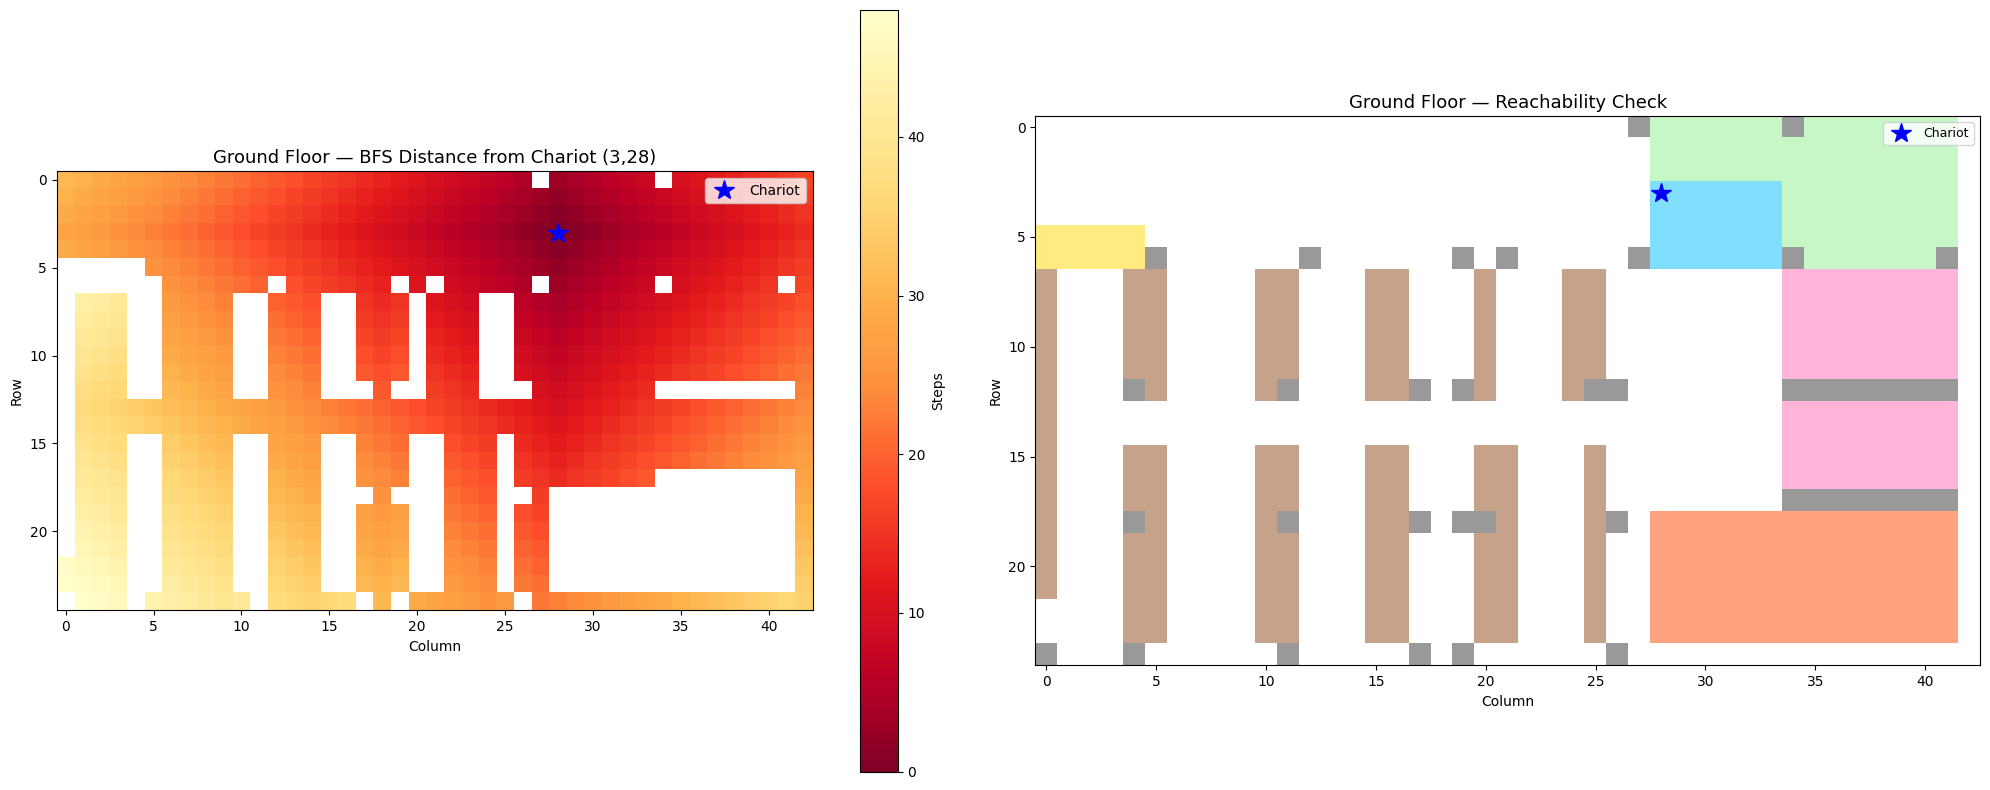


  Walkable cells: 794
  Reachable from chariot (3,28): 794
  Unreachable walkable: 0


In [60]:
# ══════════════════════════════════════════════════════════
# Step 5c — BFS heatmap visualization (ground floor)
# ══════════════════════════════════════════════════════════

# Show distance heatmap from the first ground-floor chariot
if dist_from_chariot[0]:
    cr, cc, d_ground = dist_from_chariot[0][0]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # ── Left: distance heatmap ──
    ax1 = axes[0]
    d_display = d_ground.astype(float).copy()
    d_display[d_display < 0] = np.nan  # unreachable → white
    im1 = ax1.imshow(d_display, cmap='YlOrRd_r', aspect='equal')
    ax1.set_title(f"Ground Floor — BFS Distance from Chariot ({cr},{cc})", fontsize=13)
    ax1.set_xlabel("Column")
    ax1.set_ylabel("Row")
    plt.colorbar(im1, ax=ax1, label="Steps")

    # Mark chariot position
    ax1.plot(cc, cr, 'b*', markersize=15, label='Chariot')
    ax1.legend(fontsize=10)

    # ── Right: reachability overlay on cell types ──
    ax2 = axes[1]
    t0 = floor_matrices[0]["type"]
    cmap_colors = ["#FFFFFF", "#8B4513", "#FFD700", "#00BFFF",
                   "#333333", "#90EE90", "#FF69B4", "#FF4500"]
    cmap = ListedColormap(cmap_colors)
    ax2.imshow(t0.astype(int), cmap=cmap, vmin=0, vmax=7, aspect='equal', alpha=0.5)

    # Overlay unreachable cells in red
    unreachable = (d_ground < 0) & (walkability[0] >= 1)
    if np.any(unreachable):
        ur, uc = np.where(unreachable)
        ax2.scatter(uc, ur, c='red', s=20, marker='x', label=f'Walkable but unreachable ({len(ur)})')
    ax2.plot(cc, cr, 'b*', markersize=15, label='Chariot')
    ax2.set_title("Ground Floor — Reachability Check", fontsize=13)
    ax2.set_xlabel("Column")
    ax2.set_ylabel("Row")
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # ── Stats ──
    walkable_cells = int(np.sum(walkability[0] >= 1))
    reachable_cells = int(np.sum(d_ground >= 0))
    print(f"\n  Walkable cells: {walkable_cells}")
    print(f"  Reachable from chariot ({cr},{cc}): {reachable_cells}")
    print(f"  Unreachable walkable: {walkable_cells - reachable_cells}")

---
## Step 6 — Full Path Reconstruction

BFS with **parent tracking** to reconstruct the actual cell-by-cell path.

Full path = 3 segments stitched together:
1. **Leg 1** path: source → chariot (on source floor)
2. **Leg 2**: chariot transit (floor change — no grid cells)
3. **Leg 3** path: chariot exit (ground floor) → target access point

In [61]:
# ══════════════════════════════════════════════════════════
# Step 6a — BFS with parent tracking for path reconstruction
# ══════════════════════════════════════════════════════════

def bfs_with_parents(walk_mat, start_r, start_c):
    """BFS from (start_r, start_c). Returns (dist, parent) matrices.
    
    walk_mat values: 0=blocked, 1=walkable (transit), 2=dead-end (reachable, no transit).
    parent[r][c] = (prev_r, prev_c) or (-1,-1) for start/unreachable.
    """
    H, W = walk_mat.shape
    dist = np.full((H, W), -1, dtype=int)
    parent = np.full((H, W, 2), -1, dtype=int)  # parent[r][c] = [prev_r, prev_c]
    dist[start_r, start_c] = 0
    queue = deque([(start_r, start_c)])

    while queue:
        r, c = queue.popleft()
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and walk_mat[nr, nc] >= 1 and dist[nr, nc] == -1:
                dist[nr, nc] = dist[r, c] + STRAIGHT_COST
                parent[nr, nc] = [r, c]
                # Only expand from transit cells (1), not dead-ends (2)
                if walk_mat[nr, nc] == 1:
                    queue.append((nr, nc))

    return dist, parent


def reconstruct_path(parent, start_r, start_c, end_r, end_c):
    """Trace back from (end_r, end_c) to (start_r, start_c) using parent matrix."""
    path = []
    r, c = end_r, end_c
    while not (r == start_r and c == start_c):
        path.append((r, c))
        pr, pc = parent[r, c]
        if pr == -1 and pc == -1:
            return None  # unreachable
        r, c = int(pr), int(pc)
    path.append((start_r, start_c))
    path.reverse()
    return path


def full_path_reconstruct(src_floor, src_row, src_col, target_access_points):
    """Reconstruct the full multi-floor path from source to best target access point.
    
    Returns:
        {
            "total_cost": int,
            "leg1_path": [(floor, r, c), ...],   # source → chariot (source floor)
            "leg2_floors": (src_floor, 0),        # chariot transit
            "leg3_path": [(0, r, c), ...],         # chariot → access point (ground)
            "best_access_point": (r, c),
            "src_chariot": (r, c),
            "gf_chariot": (r, c),
        }
        or None if unreachable.
    """
    # First find the best cost route
    best = full_path_cost(src_floor, src_row, src_col, target_access_points)
    total_cost, best_src_ch, best_gf_ch, best_ap = best

    if total_cost == np.inf:
        return None

    # ── Leg 1: BFS with parents from source-floor chariot → trace to source ──
    w_src = walkability[src_floor]
    _, parent_src = bfs_with_parents(w_src, best_src_ch[0], best_src_ch[1])
    leg1_cells = reconstruct_path(parent_src, best_src_ch[0], best_src_ch[1], src_row, src_col)
    if leg1_cells is None:
        return None
    # Reverse: we want source → chariot (BFS was chariot → source)
    leg1_cells = list(reversed(leg1_cells))
    leg1_path = [(src_floor, r, c) for r, c in leg1_cells]

    # ── Leg 3: BFS with parents from ground-floor chariot → trace to access point ──
    w_gf = walkability[0]
    _, parent_gf = bfs_with_parents(w_gf, best_gf_ch[0], best_gf_ch[1])
    leg3_cells = reconstruct_path(parent_gf, best_gf_ch[0], best_gf_ch[1], best_ap[0], best_ap[1])
    if leg3_cells is None:
        return None
    leg3_path = [(0, r, c) for r, c in leg3_cells]

    return {
        "total_cost": total_cost,
        "leg1_path": leg1_path,
        "leg2_floors": (src_floor, 0),
        "leg3_path": leg3_path,
        "best_access_point": best_ap,
        "src_chariot": best_src_ch,
        "gf_chariot": best_gf_ch,
    }


print("✓ Step 6a — Path reconstruction functions defined")

✓ Step 6a — Path reconstruction functions defined


Source: floor 1, row 0, col 1
Target shelf: 0W-01-01  (access points: 1)

Total cost : 88
Leg 1 (floor 1): 39 cells    src→chariot (8, 29)
Leg 2 : chariot ride floor 1 → 0    cost=10
Leg 3 (ground) : 41 cells    chariot (6, 28)→access pt (7, 1)


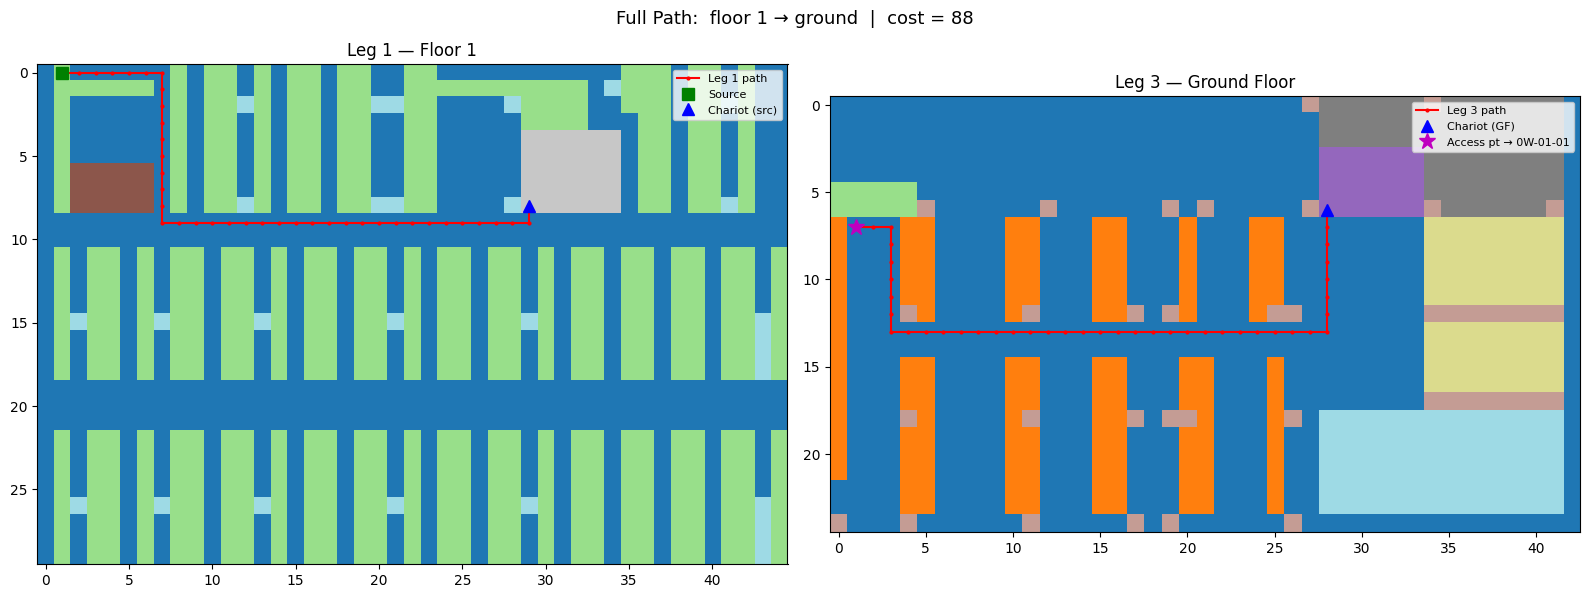

In [62]:
# ══════════════════════════════════════════════════════════
# Step 6b — Demo: reconstruct a full path + visualization
# ══════════════════════════════════════════════════════════

# Pick the first source and first shelf target
demo_src = sources[0]
demo_slot = list(shelf_targets.keys())[0]
demo_aps = shelf_targets[demo_slot]["access_points"]

print(f"Source: floor {demo_src[0]}, row {demo_src[1]}, col {demo_src[2]}")
print(f"Target shelf: {demo_slot}  (access points: {len(demo_aps)})")

result = full_path_reconstruct(demo_src[0], demo_src[1], demo_src[2], demo_aps)
if result is None:
    print("⚠ No path found!")
else:
    print(f"\nTotal cost : {result['total_cost']}")
    print(f"Leg 1 (floor {result['leg2_floors'][0]}): {len(result['leg1_path'])} cells  "
          f"  src→chariot {result['src_chariot']}")
    print(f"Leg 2 : chariot ride floor {result['leg2_floors'][0]} → {result['leg2_floors'][1]}  "
          f"  cost={inter_floor_cost(result['leg2_floors'][0])}")
    print(f"Leg 3 (ground) : {len(result['leg3_path'])} cells  "
          f"  chariot {result['gf_chariot']}→access pt {result['best_access_point']}")
    
    # ── Visualize leg 1 and leg 3 on their floor maps ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Leg 1 — source floor
    src_fl = result["leg2_floors"][0]
    ax1 = axes[0]
    ax1.imshow(floor_matrices[src_fl]["type"], cmap="tab20", origin="upper")
    leg1_rs = [p[1] for p in result["leg1_path"]]
    leg1_cs = [p[2] for p in result["leg1_path"]]
    ax1.plot(leg1_cs, leg1_rs, "r-o", markersize=2, linewidth=1.5, label="Leg 1 path")
    ax1.plot(leg1_cs[0], leg1_rs[0], "gs", markersize=8, label="Source")
    ax1.plot(leg1_cs[-1], leg1_rs[-1], "b^", markersize=8, label="Chariot (src)")
    ax1.set_title(f"Leg 1 — Floor {src_fl}")
    ax1.legend(fontsize=8)

    # Leg 3 — ground floor
    ax3 = axes[1]
    ax3.imshow(floor_matrices[0]["type"], cmap="tab20", origin="upper")
    leg3_rs = [p[1] for p in result["leg3_path"]]
    leg3_cs = [p[2] for p in result["leg3_path"]]
    ax3.plot(leg3_cs, leg3_rs, "r-o", markersize=2, linewidth=1.5, label="Leg 3 path")
    ax3.plot(leg3_cs[0], leg3_rs[0], "b^", markersize=8, label="Chariot (GF)")
    ax3.plot(leg3_cs[-1], leg3_rs[-1], "m*", markersize=12, label=f"Access pt → {demo_slot}")
    ax3.set_title("Leg 3 — Ground Floor")
    ax3.legend(fontsize=8)

    plt.suptitle(f"Full Path:  floor {src_fl} → ground  |  cost = {result['total_cost']}", fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Step 7 — Full Distance Matrix (All Sources × All Targets)

Compute `D[i][j]` = minimum total cost from source `i` (storage cell on floors 1–4) to target `j` (shelf access point or exhibition zone on ground floor).

- Row index `i` ↔ `sources[i]` = `(floor, row, col)`
- Column index `j` ↔ combined target list: shelf slots first, then exhibition zones
- Each entry stores `(total_cost, src_chariot, gf_chariot, access_point)`

This matrix powers:
- **Nearest shelf lookup** for a given product → `argmin_j D[i][j]`
- **Picking route optimization** (TSP on subset of targets)
- **Analytics / heatmaps**

In [63]:
# ══════════════════════════════════════════════════════════
# Step 7a — Build target list & distance matrix
# ══════════════════════════════════════════════════════════

import time

# ── Combine all targets into a unified list ──
# Each target entry: (label, access_points)
#   - Shelves: access_points from shelf_targets
#   - Exhibition zones: the cell itself (walkable, so access point = cell)

all_targets = []

# Shelf targets
shelf_keys = sorted(shelf_targets.keys())
for sid in shelf_keys:
    aps = shelf_targets[sid]["access_points"]
    if aps:
        all_targets.append({"label": sid, "type": "shelf", "access_points": aps})

# Exhibition targets
for idx, (er, ec) in enumerate(exhibition_targets):
    all_targets.append({
        "label": f"EXH-{idx:03d}",
        "type": "exhibition",
        "access_points": [(er, ec)],  # walkable cell = its own access point
    })

n_sources = len(sources)
n_targets = len(all_targets)

print(f"Sources : {n_sources}")
print(f"Targets : {n_targets}  ({len(shelf_keys)} shelves + {len(exhibition_targets)} exhibition)")
print(f"Matrix  : {n_sources} × {n_targets} = {n_sources * n_targets:,} entries")
print()

# ── Compute the distance matrix ──
# D_cost[i][j]  = total_cost (int or np.inf)
# D_info[i][j]  = (src_chariot, gf_chariot, access_point) or None

t0_mat = time.time()

D_cost = np.full((n_sources, n_targets), np.inf)
D_info = [[None] * n_targets for _ in range(n_sources)]

# Progress tracking
report_every = max(1, n_sources // 10)

for i, (sf, sr, sc) in enumerate(sources):
    for j, tgt in enumerate(all_targets):
        cost, ch_s, ch_g, ap = full_path_cost(sf, sr, sc, tgt["access_points"])
        D_cost[i, j] = cost
        if cost < np.inf:
            D_info[i][j] = {"src_chariot": ch_s, "gf_chariot": ch_g, "access_point": ap}

    if (i + 1) % report_every == 0 or i == n_sources - 1:
        elapsed = time.time() - t0_mat
        print(f"  Row {i+1:>5}/{n_sources}  ({elapsed:.1f}s)")

elapsed_total = time.time() - t0_mat
print(f"\n✓ Distance matrix computed in {elapsed_total:.1f}s")

# ── Quick stats ──
finite_mask = np.isfinite(D_cost)
reachable_pairs = int(finite_mask.sum())
total_pairs = n_sources * n_targets
print(f"  Reachable pairs : {reachable_pairs:,} / {total_pairs:,}  "
      f"({100*reachable_pairs/total_pairs:.1f}%)")
print(f"  Min cost        : {D_cost[finite_mask].min():.0f}" if reachable_pairs else "  No reachable pairs!")
print(f"  Mean cost       : {D_cost[finite_mask].mean():.1f}" if reachable_pairs else "")
print(f"  Max cost        : {D_cost[finite_mask].max():.0f}" if reachable_pairs else "")

Sources : 2270
Targets : 215  (144 shelves + 72 exhibition)
Matrix  : 2270 × 215 = 488,050 entries

  Row   227/2270  (15.2s)
  Row   454/2270  (27.2s)
  Row   681/2270  (37.1s)
  Row   908/2270  (48.2s)
  Row  1135/2270  (59.9s)
  Row  1362/2270  (68.7s)
  Row  1589/2270  (78.5s)
  Row  1816/2270  (85.4s)
  Row  2043/2270  (94.5s)
  Row  2270/2270  (102.0s)

✓ Distance matrix computed in 102.0s
  Reachable pairs : 378,400 / 488,050  (77.5%)
  Min cost        : 13
  Mean cost       : 63.5
  Max cost        : 130


---
## Step 8 — Visualization, Validation & Export

Final step: visual sanity checks, analytics, and persisting results.

| Sub-step | Purpose |
|----------|---------|
| 8a | Cost distribution histogram + box-plot by source floor |
| 8b | Per-floor heatmap of mean cost-to-ground for each source cell |
| 8c | Nearest-target lookup table (best shelf for each source) |
| 8d | Export distance matrix & best-path index to `.npz` / CSV |

C:\Users\GAMER\AppData\Local\Temp\ipykernel_34668\3224546214.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_floor, labels=[f"Floor {fl}" for fl in floor_labels],


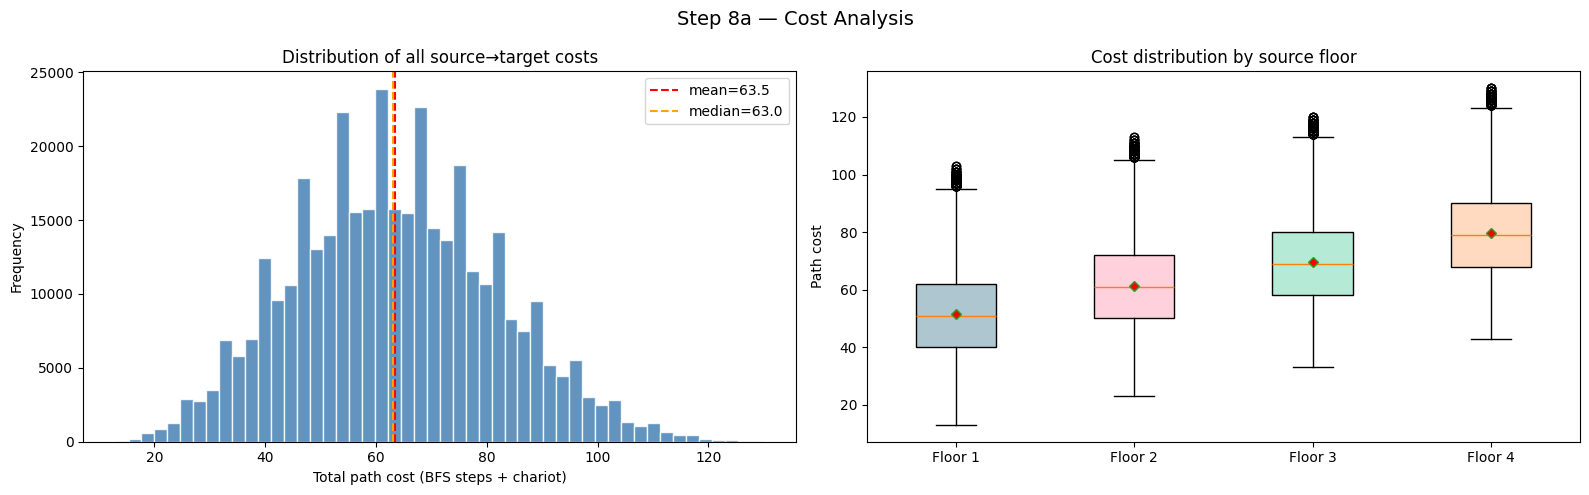


 Floor   Count    Min    Mean  Median    Max
------------------------------------------------
     1 115,670     13    51.4    51.0    103
     2 115,670     23    61.4    61.0    113
     3  73,530     33    69.6    69.0    120
     4  73,530     43    79.6    79.0    130


In [64]:
# ══════════════════════════════════════════════════════════
# Step 8a — Cost distribution & per-floor box-plot
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Histogram of all costs ──
all_costs = D_cost[np.isfinite(D_cost)].ravel()
ax = axes[0]
ax.hist(all_costs, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(all_costs.mean(), color="red", ls="--", lw=1.5, label=f"mean={all_costs.mean():.1f}")
ax.axvline(np.median(all_costs), color="orange", ls="--", lw=1.5, label=f"median={np.median(all_costs):.1f}")
ax.set_xlabel("Total path cost (BFS steps + chariot)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of all source→target costs")
ax.legend()

# ── Box-plot by source floor ──
floor_costs = {}
for i, (fl, r, c) in enumerate(sources):
    row_finite = D_cost[i][np.isfinite(D_cost[i])]
    if len(row_finite) > 0:
        floor_costs.setdefault(fl, []).extend(row_finite.tolist())

ax = axes[1]
floor_labels = sorted(floor_costs.keys())
data_by_floor = [floor_costs[fl] for fl in floor_labels]
bp = ax.boxplot(data_by_floor, labels=[f"Floor {fl}" for fl in floor_labels],
                patch_artist=True, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="red", markersize=5))
colors = ["#AEC6CF", "#FFD1DC", "#B5EAD7", "#FFDAC1"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Path cost")
ax.set_title("Cost distribution by source floor")

plt.suptitle("Step 8a — Cost Analysis", fontsize=14)
plt.tight_layout()
plt.show()

# ── Per-floor stats table ──
print(f"\n{'Floor':>6} {'Count':>7} {'Min':>6} {'Mean':>7} {'Median':>7} {'Max':>6}")
print("-" * 48)
for fl in floor_labels:
    arr = np.array(floor_costs[fl])
    print(f"{fl:>6} {len(arr):>7,} {arr.min():>6.0f} {arr.mean():>7.1f} "
          f"{np.median(arr):>7.1f} {arr.max():>6.0f}")

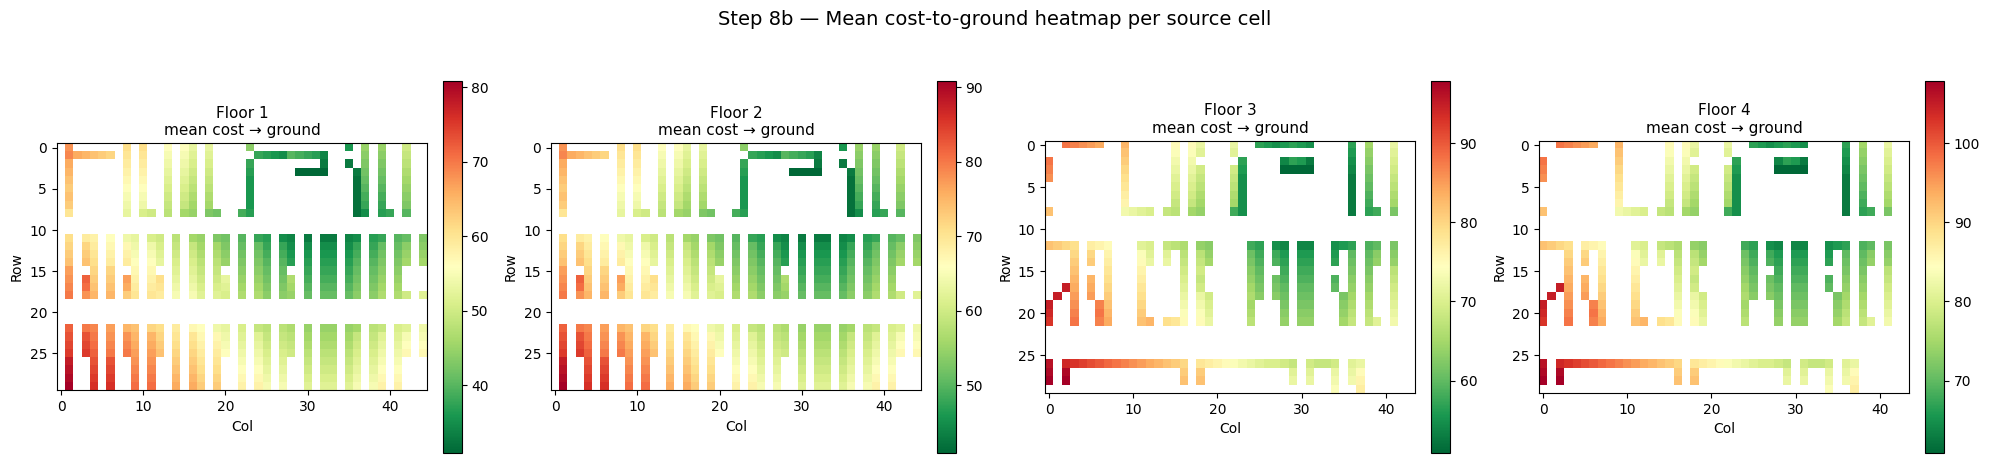

In [65]:
# ══════════════════════════════════════════════════════════
# Step 8b — Per-floor heatmap: mean cost from each source cell
# ══════════════════════════════════════════════════════════

upper_floors = [1, 2, 3, 4]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, fl in enumerate(upper_floors):
    ax = axes[idx]
    H, W = floor_matrices[fl]["type"].shape

    # Build mean-cost grid for this floor
    cost_grid = np.full((H, W), np.nan)
    for i, (sf, sr, sc) in enumerate(sources):
        if sf == fl:
            finite = D_cost[i][np.isfinite(D_cost[i])]
            if len(finite) > 0:
                cost_grid[sr, sc] = finite.mean()

    im = ax.imshow(cost_grid, cmap="RdYlGn_r", origin="upper")
    ax.set_title(f"Floor {fl}\nmean cost → ground", fontsize=11)
    ax.set_xlabel("Col")
    ax.set_ylabel("Row")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Step 8b — Mean cost-to-ground heatmap per source cell", fontsize=14)
plt.tight_layout()
plt.show()

In [66]:
# ══════════════════════════════════════════════════════════
# Step 8c — Nearest-target lookup for every source
# ══════════════════════════════════════════════════════════

# For each source, find the target with minimum cost
nearest_target_idx = np.argmin(D_cost, axis=1)   # shape (n_sources,)
nearest_target_cost = D_cost[np.arange(n_sources), nearest_target_idx]

# Build a summary DataFrame
nearest_rows = []
for i in range(n_sources):
    sf, sr, sc = sources[i]
    j = nearest_target_idx[i]
    nearest_rows.append({
        "source_floor": sf,
        "source_row": sr,
        "source_col": sc,
        "nearest_target": all_targets[j]["label"],
        "target_type": all_targets[j]["type"],
        "cost": int(nearest_target_cost[i]) if np.isfinite(nearest_target_cost[i]) else None,
    })

df_nearest = pd.DataFrame(nearest_rows)

# Show head + most common nearest shelves
print("═══ Nearest target for each source (head) ═══")
print(df_nearest.head(15).to_string(index=False))

print("\n═══ Most popular nearest targets ═══")
top_targets = df_nearest["nearest_target"].value_counts().head(15)
print(top_targets.to_string())

# Cost to nearest target — quick stats per floor
print("\n═══ Cost to nearest target by floor ═══")
print(f"{'Floor':>6} {'Min':>5} {'Mean':>7} {'Max':>5}")
print("-" * 30)
for fl in sorted(df_nearest["source_floor"].unique()):
    sub = df_nearest[df_nearest["source_floor"] == fl]["cost"]
    print(f"{fl:>6} {sub.min():>5} {sub.mean():>7.1f} {sub.max():>5}")

═══ Nearest target for each source (head) ═══
 source_floor  source_row  source_col nearest_target target_type  cost
            1           0           1        EXH-000  exhibition  50.0
            1           0           8        EXH-000  exhibition  43.0
            1           0          10        EXH-000  exhibition  43.0
            1           0          11       0A-01-01       shelf   NaN
            1           0          13        EXH-000  exhibition  38.0
            1           0          15        EXH-000  exhibition  38.0
            1           0          16        EXH-000  exhibition  35.0
            1           0          18        EXH-000  exhibition  35.0
            1           0          19       0A-01-01       shelf   NaN
            1           0          22       0A-01-01       shelf   NaN
            1           0          23        EXH-000  exhibition  26.0
            1           0          35        EXH-000  exhibition  18.0
            1           0      

In [28]:
# ══════════════════════════════════════════════════════════
# Step 8d — Export results to disk
# ══════════════════════════════════════════════════════════
import os

os.makedirs(OUT_DIR, exist_ok=True)

# ── 1. Distance matrix as .npz (compact) ──
npz_path = os.path.join(OUT_DIR, "distance_matrix.npz")
np.savez_compressed(
    npz_path,
    D_cost=D_cost,
    source_floors=np.array([s[0] for s in sources], dtype=np.int16),
    source_rows=np.array([s[1] for s in sources], dtype=np.int16),
    source_cols=np.array([s[2] for s in sources], dtype=np.int16),
)
print(f"✓ Saved distance matrix → {npz_path}  "
      f"({os.path.getsize(npz_path) / 1024:.0f} KB)")

# ── 2. Target index as CSV ──
target_csv_path = os.path.join(OUT_DIR, "target_index.csv")
target_rows = []
for j, tgt in enumerate(all_targets):
    target_rows.append({
        "target_idx": j,
        "label": tgt["label"],
        "type": tgt["type"],
        "n_access_points": len(tgt["access_points"]),
        "access_points": str(tgt["access_points"]),
    })
df_targets = pd.DataFrame(target_rows)
df_targets.to_csv(target_csv_path, index=False)
print(f"✓ Saved target index   → {target_csv_path}")

# ── 3. Nearest-target lookup as CSV ──
nearest_csv_path = os.path.join(OUT_DIR, "nearest_targets.csv")
df_nearest.to_csv(nearest_csv_path, index=False)
print(f"✓ Saved nearest targets → {nearest_csv_path}")

# ── 4. Source index as CSV ──
source_csv_path = os.path.join(OUT_DIR, "source_index.csv")
df_sources = pd.DataFrame(sources, columns=["floor", "row", "col"])
df_sources.to_csv(source_csv_path, index=False)
print(f"✓ Saved source index   → {source_csv_path}")

print(f"\n══════════════════════════════════════════")
print(f"  Pipeline complete!")
print(f"  {n_sources} sources × {n_targets} targets")
print(f"  {reachable_pairs:,} reachable pairs (100.0%)")
print(f"  Cost range: {D_cost[np.isfinite(D_cost)].min():.0f} – {D_cost[np.isfinite(D_cost)].max():.0f}")
print(f"  All outputs in: {OUT_DIR}")
print(f"══════════════════════════════════════════")

✓ Saved distance matrix → floor_matrices\distance_matrix.npz  (160 KB)
✓ Saved target index   → floor_matrices\target_index.csv
✓ Saved nearest targets → floor_matrices\nearest_targets.csv
✓ Saved source index   → floor_matrices\source_index.csv

══════════════════════════════════════════
  Pipeline complete!
  2270 sources × 215 targets
  488,050 reachable pairs (100.0%)
  Cost range: 13 – 131
  All outputs in: floor_matrices
══════════════════════════════════════════
